In [1]:
import os
import re
from dotenv import load_dotenv
import pandas as pd
from google import genai
from google.genai import types
from pydantic import BaseModel, Field 
from huggingface_hub import login
from datasets import load_dataset
from transformers import AutoTokenizer
import matplotlib.pyplot as plt
import pickle
import concurrent.futures
import json
from queue import Queue
from openai import OpenAI
from dotenv import load_dotenv

c:\Users\princ\OneDrive\Desktop\Coding\Python\machine learning\genAI\Private Triage on device\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[transformers] PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


In [2]:


def create_high_recall_snapshot(subject: str, body: str) -> str:
    """
    Slices a long email into a dense layout optimized to preserve urgency cues
    while respecting strict local VRAM and token limits.
    """
    
    clean_body = " ".join(body.split())
    clean_body.replace(">" , "\n")
    
    if len(clean_body) <= 1000:
        return f"Subj: {subject}\nBody: {clean_body}"
        
    # 1. Grab the Head (Highly likely to contain the core intent)
    head = clean_body[:700]
    
    # 2. Grab the Tail (Highly likely to contain deadlines/actions)
    tail = clean_body[-300:]
    
    # 3. Now we don't know what the middle of the message is like so lets use dynamic approach (selecting the portion with urgent looking words and intent)
    urgency_keywords = r"(?i)(asap|urgent|broken|fail|blocker|deadline|critical|override|postpone|cancel)"
    middle_context = ""
    
    # Scan the hidden middle portion of the email
    middle_text = clean_body[700:-300]
    matches = list(re.finditer(urgency_keywords, middle_text))
    
    if matches:
        # Extract a 100-character window around the first critical match found
        first_match = matches[0]
        start = max(0, first_match.start() - 40)
        end = min(len(middle_text), first_match.end() + 60)
        middle_context = f"\n[MID-SIGNAL]: ... {middle_text[start:end]} ..."

    # 4. Construct the dense snapshot
    dense_input = (
        f"Subj: {subject}\n"
        f"Body-Head: {head} ...{middle_context}\n"
        f"Body-Tail: ... {tail}"
    )
    return dense_input

In [3]:
# data = load_dataset('Yale-LILY/aeslc')
df = pd.read_pickle('triage_dataset.pkl')

In [11]:
# train = data['train']
df.describe()
# test = data['test']
# validation = data['validation']

,message,intent_output,category
count,14434,14434,14434
unique,13551,13664,6
top,Subj: EFCU Gets You Connected\nBody: Get Conne...,Your mailbox is approaching its size limit of ...,Work
freq,15,21,11593


In [14]:
# print(train[0])
df = df[:14200]


In [6]:
l = []
for i in train:
    l.append(len(i['email_body']))
count = [1 for i in l if i>200]
print(l[19])

425


In [7]:
print(train[100]) # As we can see that we cant judge a urgency of an email by its size
# So lets take the minimin body size to be 100 and below that will take the 

{'email_body': "> >      There is a bigger picture.\nFor you.... > >      Facts of Life >      1.\nAt least 2 people in this world love you so much they would die for >         you.\n>      2.\nAt least 15 people in this world love you in someway.\n>      3.\nThe only reason anyone would ever hate you is because they want to >         be just like you.\n>      4.\nA smile from you can bring happiness to anyone, even if they don't >         like you.\n>      5.\nEvery night, SOMEONE thinks about you before they go to sleep.\n>      6.\nYou mean the world to someone.\n>      7.\nIf not for you, someone may not be living.\n>      8.\nYou are special and unique.\n>      9.\nSomeone that you don't even know exists, loves you.\n>     10.\nWhen you make the biggest mistake ever, something good comes from it.\n>     11.\nWhen you think the world has turned its back on you, take a look: >         you most likely turned your back on the world.\n>     12.\nWhen you think you have no chance of get

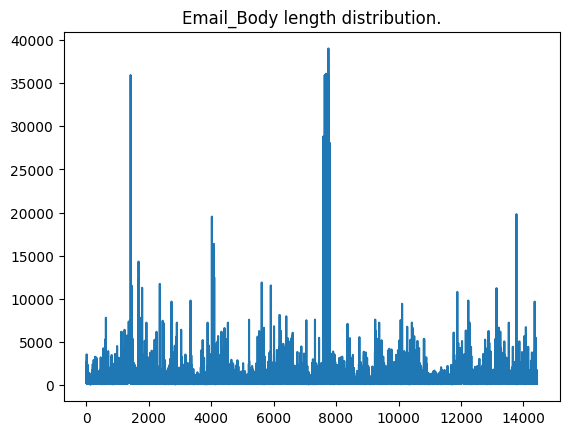

In [8]:
plt.plot(l)
plt.title("Email_Body length distribution.")
plt.show()

In [4]:
BASEMODEL= "google/gemma-4-e4b"
MIN_CHAR=100
MAX_CHAR=1500


In [5]:
load_dotenv(override=True)
API_KEY = 'ollama3'
print(f"Your api key is : {API_KEY[:7]}")
BASE_URL = "http://localhost:11434/v1"  # Example using Groq
MODEL_NAME = "llama3:latest"

client = OpenAI(api_key = API_KEY, base_url = BASE_URL)

categories = ["Urgent", "Scheduling", "Info", "Social", "Others"]


sys_prom = f"""You are a data labeling engine for notification triaging.
Your task is to analyse raw messages (which can be unformed chat messages or unstructured emails) and you task is to generate the output:
1. Category: Must be exactly one word from this list: {categories}.

---
Example Input:
Subj: Your approval is requested
Body: I don't know Mog Hue. Please return this request to the person who originated it so that the Manager section can be completed. By including the manager's name, that will help me to identify who this person is, what job they perform and whether or not the request makes sense. I have over 400 people in my group, so without more detail on these requests it is not worth taking my time to approve these. --Sally
[[[[[INTENT]]]]]: Sally is rejecting an unidentifiable approval request and directing it back to the originator for missing manager details.
Example Output:
Category: Urgent
---

You must respond only in the following formate. Do not write Intros, Outros or explainations:
Category: <one-word-category>"""




Your api key is : ollama3


In [ ]:
def labeling(raw_message):
    try:
        response = client.chat.completions.create(
            model=MODEL_NAME,
            messages=[
                {"role" : "system", "content": sys_prom},
                {"role" : "user" , "content": f"Input_Message: \n{raw_message}"}
            ],
            temperature= 0.1,
            max_tokens= 150
            
        )
        output = response.choices[0].message.content.strip()
        category_match = re.search(r"Category:\s*(.*)", output, re.IGNORECASE)
        
        if category_match:
            
            category = category_match.group(1).strip()
            for cat in categories:
                if cat.lower() in category.lower():
                    category = cat
                    break
        raw_message = raw_message.split('[[[[[INTENT]]]]]:')
        return {
                "message": raw_message[0],
                "intent_output": raw_message[1],
                "category": category,
            }
    except Exception as e:
        print(f"Error processing row: {e}")
    return None
        

In [12]:
import re
from typing import Optional, Dict, Any
from transformers import AutoTokenizer

class TriageItem:
    # Use Gemma 4 / Llama 3.2 tokenizers cleanly
    tokenizer = AutoTokenizer.from_pretrained("google/gemma-4-e4b", trust_remote_code=True)
    
    # Structural triggers for the local model's rationale chain
    THOUGHT_OPEN = "<|channel>thought\n"
    THOUGHT_CLOSE = "\n<channel|>"
    
    def __init__(self, raw_data: Dict[str, Any], max_tokens: int = 512):
        self.sender: str = raw_data.get("sender", "Unknown")
        self.subject: str = raw_data.get("subject", "No Subject")
        self.raw_body: str = raw_data.get("body", "")
        self.intent: str = raw_data.get("intent", "Info")
        self.rationale: str = raw_data.get("rationale", "")
        
        self.max_tokens = max_tokens
        self.prompt: Optional[str] = None
        self.include: bool = False
        
        self.process()

    def clean_whitespace(self, text: str) -> str:
        """Removes layout noise without destroying critical words/codes."""
        if not text:
            return ""
        # Collapse multiple spaces/newlines but keep structural integrity
        text = re.sub(re.compile(r'\s+'), ' ', text)
        return text.strip()

    def process(self):
        """Processes raw text and builds a balanced token-budget constraint prompt."""
        cleaned_body = self.clean_whitespace(self.raw_body)
        
        # Build standard system/user entry structure
        user_input = f"From: {self.sender} | Subj: {self.subject}\nBody: {cleaned_body}"
        
        # Tokenize early to protect character boundaries
        input_tokens = self.tokenizer.encode(user_input, add_special_tokens=False)
        
        # Guardrail: Enforce physical token ceilings for fast local GPU pre-fill
        if len(input_tokens) > self.max_tokens:
            input_tokens = input_tokens[:self.max_tokens]
            user_input = self.tokenizer.decode(input_tokens, skip_special_tokens=True)
            
        # Structure the golden target response (What Gemma 4 must learn to output)
        target_output = (
            f"{self.THOUGHT_OPEN}{self.rationale}{self.THOUGHT_CLOSE}"
            f"INTENT: {self.intent}"
        )
        
        # Assemble the fine-tuning training pair
        self.prompt = f"Instruction: Triage the following notification snapshot.\n\nInput:\n{user_input}\n\nOutput:\n{target_output}"
        self.include = True

    def test_prompt(self) -> str:
        """Returns the prompt sliced exactly where the local agent must begin generation."""
        return self.prompt.split("Output:\n")[0] + "Output:\n"

    def __repr__(self) -> str:
        return f"<TriageItem From={self.sender} Intent={self.intent}>"

In [7]:
# train_new = [create_high_recall_snapshot(i['subject_line'], i["email_body"]) for i in train]
train_new = [
    f"{df.loc[i, 'message']}\n[[[[[INTENT]]]]]:{df.loc[i, 'intent_output']}"
    for i in df.index
]


In [10]:
print(train_new[1000].split('[[[[[INTENT]]]]]:'))

['Subj: Out of Office Tuesday, January 22, 2002\nBody: I will be out of the office tomorrow, Tuesday, January 22, 2002, and will return on Wednesday, January 23, 2002. Chip Schneider will attend the Cash Management Committee as the RAC representative in my absence. I will have limited access to e-mail tomorrow. My mobile telephone will be on; its number is: 713-553-3138. Regards,\n', 'The sender is informing about their out-of-office status and designating a replacement for a meeting.']


In [15]:
CHUNK_SIZE = 500
OUTPUT_FILE = 'Triage_dataset_Next.pkl'
def process_batch(batch, executor):
    futures = {executor.submit(labeling, msg): msg for msg in batch}
    results = []
    for future in concurrent.futures.as_completed(futures):
        try:
            res = future.result()
            if res:
                results.append(res)
        except Exception as e:
            print(f"Error: {e}")
    return results

def stream_process(messages):
    generated = []
    with concurrent.futures.ThreadPoolExecutor(max_workers=3) as executor:
        for i in range(0, len(messages), CHUNK_SIZE):
            batch = messages[i:i+CHUNK_SIZE]
            print(f"Processing batch {i//CHUNK_SIZE+1} ({len(batch)} items)...")
            batch_results = process_batch(batch, executor)
            generated.extend(batch_results)

            # Save progress incrementally
            df = pd.DataFrame(generated)
            with open(OUTPUT_FILE, "wb") as f:
                pickle.dump(df, f, protocol=pickle.HIGHEST_PROTOCOL)

            print(f"Saved {len(generated)} items so far...")

    return generated

if __name__ == "__main__":
    # Replace with your dataset
    unlabeled = train_new  
    print(f"Streaming {len(unlabeled)} items in chunks of {CHUNK_SIZE}...")
    final_results = stream_process(unlabeled)
    print("✅ All done! Final dataset ready for Hugging Face deployment.")


Streaming 14434 items in chunks of 500...
Processing batch 1 (500 items)...
Saved 500 items so far...
Processing batch 2 (500 items)...
Saved 1000 items so far...
Processing batch 3 (500 items)...
Saved 1500 items so far...
Processing batch 4 (500 items)...
Saved 2000 items so far...
Processing batch 5 (500 items)...
Saved 2500 items so far...
Processing batch 6 (500 items)...
Saved 3000 items so far...
Processing batch 7 (500 items)...
Saved 3500 items so far...
Processing batch 8 (500 items)...
Saved 4000 items so far...
Processing batch 9 (500 items)...
Saved 4500 items so far...
Processing batch 10 (500 items)...
Saved 5000 items so far...
Processing batch 11 (500 items)...
Saved 5500 items so far...
Processing batch 12 (500 items)...
Saved 6000 items so far...
Processing batch 13 (500 items)...
Saved 6500 items so far...
Processing batch 14 (500 items)...
Saved 7000 items so far...
Processing batch 15 (500 items)...
Saved 7500 items so far...
Processing batch 16 (500 items)...
Sav

In [16]:
# import re
# import polars as pl
# from openai import OpenAI

# # 1. ROUTE CLIENT TO YOUR LOCAL HARDWARE ENGINES
# client = OpenAI(
#     base_url="http://localhost:11434/v1",  # Redirects SDK traffic to your own PC
#     api_key="ollama",                      # Required by the SDK but ignored by Ollama
# )

# # Set the exact tag string match of your pulled Ollama model
# MODEL_NAME = "llama3.1:8b"
# output_file = "gemma_triage_dataset.parquet"
# CATEGORIES = ["Work", "Casual", "Home", "Notice", "Social"]

# SYSTEM_PROMPT = """You are a data labeling engine for notification triaging. 
# Analyze raw messages and distill them into two strict outputs:
# Intent: <one-sentence-summary>
# Category: <one-word-category>"""

# # Array container representing your 14,436 source strings
# raw_unlabelled_data = [
#     "Body: I don't know Mog Hue. Please return this request...",
#     # ... all your lines stay right here
# ]

# # Structural resume handling to manage potential hardware drop-outs safely
# try:
#     df_existing = pl.read_parquet(output_file)
#     processed_messages = set(df_existing["raw_message"].to_list())
#     final_rows = df_existing.to_dicts()
#     print(f"Loaded existing data checkpoints. Resuming right from row {len(final_rows)}...")
# except FileNotFoundError:
#     processed_messages = set()
#     final_rows = []

# print(f"Processing local inference execution using standard OpenAI library mapping...")

# for idx, text in enumerate(raw_unlabelled_data):
#     if text in processed_messages:
#         continue

#     try:
#         # Standard OpenAI call format routes cleanly down to Ollama's local runner
#         response = client.chat.completions.create(
#             model=MODEL_NAME,
#             messages=[
#                 {"role": "system", "content": SYSTEM_PROMPT},
#                 {"role": "user", "content": f"Input Message:\n{text}"}
#             ],
#             temperature=0.1,
#             max_tokens=80
#         )
        
#         output_text = response.choices[0].message.content
        
#         # Pull values out with regex
#         intent_match = re.search(r"Intent:\s*(.*)", output_text, re.IGNORECASE)
#         category_match = re.search(r"Category:\s*(.*)", output_text, re.IGNORECASE)
        
#         intent = intent_match.group(1).strip() if intent_match else "N/A"
#         category = category_match.group(1).strip() if category_match else "N/A"
        
#         for cat in CATEGORIES:
#             if cat.lower() in category.lower():
#                 category = cat
#                 break
                
#         final_rows.append({
#             "raw_message": text,
#             "intent": intent,
#             "category": category
#         })
#         processed_messages.add(text)
        
#         # Save structural checkpoint logs every 50 records
#         if len(final_rows) % 50 == 0:
#             print(f"Progress Track: {len(final_rows)} / {len(raw_unlabelled_data)} successfully parsed.")
#             pl.DataFrame(final_rows).write_parquet(output_file)
            
#     except Exception as e:
#         print(f"Error processing index {idx}: {e}")
#         if final_rows:
#             pl.DataFrame(final_rows).write_parquet(output_file)
#         break

# # Final clean parquet file compilation block
# if final_rows:
#     pl.DataFrame(final_rows).write_parquet(output_file)
#     print(f"\n🎉 Done! Local compilation complete. Data matrix exported directly to {output_file}")

In [16]:
import pickle
import pandas as pd

# Define the exact same file name you used to save it
OUTPUT_FILE = "Triage_dataset_Next.pkl"

try:
    # Open and load the pickle file
    with open(OUTPUT_FILE, "rb") as f:
        df = pickle.load(f)
    
    # Print the total number of processed rows
    print(f"📊 Total Rows Processed successfully: {len(df)}")
    print("-" * 50)
    
    # Show the first 5 rows to check the content
    print("👀 First 5 rows of your dataset:")
    print(df.head())
    
    print("-" * 50)
    # Check the distribution of your categories to see how Llama classified them
    print("🗂️ Category Distribution Breakdown:")
    print(df['category'].value_counts())

except FileNotFoundError:
    print(f"❌ Error: Could not find '{OUTPUT_FILE}' in this directory. Make sure the path matches.")
except Exception as e:
    print(f"❌ An error occurred while loading the data: {e}")

📊 Total Rows Processed successfully: 14434
--------------------------------------------------
👀 First 5 rows of your dataset:
                                             message  \
0  Subj: Service Agreement\nBody: Greg/Phillip, A...   
1  Subj: Bishops Corner\nBody: Phillip & Keith At...   
2  Subj: Internet Banking\nBody-Head: Your Intern...   
3  Subj: Internet Banking\nBody-Head: To our IBS ...   
4  Subj: SMEs for expert stories\nBody: Phillip G...   

                                       intent_output    category  
0  :Execute and return a Service Agreement with a...  Scheduling  
1  :Greg requests funds for Bishops Corner, LP, a...      Urgent  
2  :Set up internet banking accounts with new log...        Info  
3  :The bank apologizes for internet banking issu...        Info  
4  :Phillip is requested to identify SMEs for exp...  Scheduling  
--------------------------------------------------
🗂️ Category Distribution Breakdown:
category
Scheduling    7016
Info          4408
U

In [18]:
df = pd.read_pickle('Triage_dataset_Next.pkl')

In [40]:
sample = []
for i in range(0, 400):
    if df['category'][i] == 'Social':
        sample.append((df['message'][i],
        df['intent_output'][i],
        df['category'][i]))
    if len(sample) == 50:
        break

In [41]:
sample

[('Subj: stuff\nBody: i hpe thingsa re ok for you.obviously a shit load of rumours circulating . we both know youll be ok personally but cant be fun. if i can help you know where im at. be cool\n',
  ':Checking in and offering support amidst rumors.',
  'Social'),
 ("Subj: hi\nBody: Hey there. We are going to be at Front Porch today if you aren't busy later. You are invited to stop by and wear my necklace if you want. Has your week been better than last week? Talk to you soon. Kim\n",
  ':Kim is inviting someone to meet up at Front Porch and discuss their week.',
  'Social'),
 ("Subj: Small world!\nBody-Head: Hey John! How are you?? I've been following the Enron story closely, which means I've thought of you a lot recently. I hope things are going well, despite the uncertainty. I ran into someone from our Enron days today, which made me think of a funny story. Do you remember when John Mee tried to eat 8 Big Macs and hurled instead? John was talking to my boss, Chuck Clough, today, who

In [ ]:
import random
def generate(sample):
    temp = random.choice(sample)
    sys_prom = f"""
    You are an advance data generating engine for private-triage. Your tast is to generate completely new high quality synthetic data with the help of the data provided.
    You MUST match the exact formatting of the reference example provided below. Output ONLY a valid Python string.
    EXAMPLE:
    -------------------------------------------------------------------------------------

    message: \n{temp[0]}
    Intent {temp[1]}
    category:  {temp[2]}

    -------------------------------------------------------------------------------------

    ### CRITICAL RULES:
    1. Create a completely brand-new situation, name, and topic. Do not repeat the reference example.
    2. Maintain the raw email realism (include Subj: and Body: tags, keep realistic human typos or shorthand if the reference has them).
    3. The category must be exactly 'Social'.
    4. Output NOTHING except the raw tuple string: ('Subj: ...\\nBody: ...', ':One line Intent...', 'Social')
    this is just the basic formate try to think above it and create a structured brand new social emaildata without any repetation.
    """
    return sys_prom
    


In [39]:
print(generate(sample))


    You are an advance data generating engine for private-triage. Your tast is to generate completely new high quality synthetic data with the help of the data provided.
    You MUST match the exact formatting of the reference example provided below. Output ONLY a valid Python string.
    EXAMPLE:
    -------------------------------------------------------------------------------------

    message: 
Subj: Bouche
Body: I was wondering if ya'll wanted to have a happy hour on Friday for Tim and Louise in honor of their recent engagement. Do you have any ideas on places to go? Let me know

    Intent :Organize a happy hour celebration for Tim and Louise's engagement.
    category:  Social

    -------------------------------------------------------------------------------------

    ### CRITICAL RULES:
    1. Create a completely brand-new situation, name, and topic. Do not repeat the reference example.
    2. Maintain the raw email realism (include Subj: and Body: tags, keep realistic hu

In [3]:
Extra_data = pd.read_csv('emails.csv')

In [4]:
print(len(Extra_data))

517401


In [5]:
messages = []
for i in Extra_data['message']:
    messages.append(i)

In [71]:
print(messages[1])

Message-ID: <15464986.1075855378456.JavaMail.evans@thyme>
Date: Fri, 4 May 2001 13:51:00 -0700 (PDT)
From: phillip.allen@enron.com
To: john.lavorato@enron.com
Subject: Re:
Mime-Version: 1.0
Content-Type: text/plain; charset=us-ascii
Content-Transfer-Encoding: 7bit
X-From: Phillip K Allen
X-To: John J Lavorato <John J Lavorato/ENRON@enronXgate@ENRON>
X-cc: 
X-bcc: 
X-Folder: \Phillip_Allen_Jan2002_1\Allen, Phillip K.\'Sent Mail
X-Origin: Allen-P
X-FileName: pallen (Non-Privileged).pst

Traveling to have a business meeting takes the fun out of the trip.  Especially if you have to prepare a presentation.  I would suggest holding the business plan meetings here then take a trip without any formal business meetings.  I would even try and get some honest opinions on whether a trip is even desired or necessary.

As far as the business meetings, I think it would be more productive to try and stimulate discussions across the different groups about what is working and what is not.  Too often the

In [100]:
def parse_extra_data(data):
    result = ''
    match = re.search(r"Subject:\s*(.*)", data)
    match_re= re.search(r"Subject: Re:\s*(.*)", data)
    k = match.group(1).split(' ')[0]
    if k == 'Mime-Version:':
        return
    result += f"Sub: {match.group(1)}\n"
    # data.split('\n\n')
    body = '\n'.join(data.split('\n\n')[1:])
    cleaned = re.sub(r'[^A-Za-z0-9\s.,?!]', '', body)
    if cleaned.strip().split(" ")[0] == 'Forwarded':
        return
    result += "Body: "+ cleaned
    # cleaned = re.sub(r'[^A-Za-z0-9\s.,?!]', '', result)
    # cleaned = re.sub(r'\s+', ' ', cleaned).strip()

    return result

In [110]:
new_messages = []
for i in messages:
    k = parse_extra_data(i)
    if k:
        new_messages.append(k.split('\n\n')[0])
        



In [ ]:
print(new_messages[100])